## Collect Memory requirements from STDOUT

## Visualize Requirements

In [3]:
import pybedtools, os, re
import pandas as pd
import numpy as np

from matplotlib.gridspec import GridSpec
from matplotlib import pyplot as plt
import seaborn as sns
import matplotlib

import dataframe_image as dfi

mem_df = pd.read_table("../05_footprinting/memory_stats.txt", sep=", ", engine='python')

prog = []
for i in mem_df["file"]:
    if "HINT" in i: prog=prog+["HINT"]
    elif "PWM" in i: prog=prog+["PWM"]
    elif "TOBIAS" in i: prog=prog+["TOBIAS"]
    elif "PRINT" in i: prog=prog+["PRINT"]
    elif "MACS3" in i: prog=prog+["MACS3"]
    else: prog=prog+["UNKNOWN"]

mem_df["program"] = prog
mem_df = mem_df.replace(',', np.NaN, regex=True)
mem_df= mem_df[mem_df.program != "UNKNOWN"]
mem_df= mem_df[mem_df['cpu'].notna()]
display(mem_df)

# rows_with_na = mem_df[mem_df.isna().any(axis=1)]
# display(rows_with_na)

,file,cpu,mem(GBs),io(GB),vmem(M),maxvmem(M),nproc,time(s),inputfilesize(B),program
0,MCF7-cellFilt_PWM.qsub.sh.o1516186,00:37:53,32143.34101,12.77125,42.179G,43.941G,1.0,2435.0,19253200.0,PWM
1,K562-cellFilt_PWM.qsub.sh.o1516185,01:08:01,78229.77430,17.35846,52.088G,53.422G,1.0,4218.0,25444953.0,PWM
2,SKNSH-cellFilt_PWM.qsub.sh.o1516187,00:44:35,42655.86119,15.34079,3.547M,48.520G,1.0,2828.0,22663178.0,PWM
3,GM12878-cellFilt_PWM.qsub.sh.o1516183,00:56:09,59168.15946,17.11201,50.176G,50.176G,1.0,3547.0,26472749.0,PWM
4,HEPG2-cellFilt_PWM.qsub.sh.o1516184,00:46:07,43438.73628,15.22689,46.068G,47.531G,1.0,2912.0,22774684.0,PWM
...,...,...,...,...,...,...,...,...,...,...
1669,HEPG2_f035_s15_MACS3.qsub.sh.o1367984,00:43:25,3418.30528,61.80130,2.954G,4.402G,5.0,2948.0,4836509.0,MACS3
1670,MCF7_f04_s97_MACS3.qsub.sh.o887364,00:27:26,1693.27199,48.84861,2.705G,3.488G,5.0,1829.0,2731720.0,MACS3
1671,MCF7_f04_s17_MACS3.qsub.sh.o887362,00:31:43,2010.31324,99.39652,4.705G,5.525G,5.0,2003.0,2727562.0,MACS3
1672,HEPG2_f06_s67_MACS3.qsub.sh.o887330,00:23:02,1117.70297,37.61238,2.039G,2.594G,5.0,1499.0,1589364.0,MACS3


In [5]:
def convert_to_gb(file_sizes):
    gb_sizes = []
    for size in file_sizes:
        if size is None or pd.isna(size):
            gb_sizes.append(None)
        elif size.endswith('B'):
            gb_sizes.append(float(size[:-1])/1e9)
        elif size.endswith('G'):
            gb_sizes.append(float(size[:-1]))
        elif size.endswith('M'):
            gb_sizes.append(float(size[:-1])/1e3)
        elif size.endswith('K'):
            gb_sizes.append(float(size[:-1])/1e6)
        elif size.endswith('T'):
            gb_sizes.append(float(size[:-1])*1e3)
        else:
            print(size)
            raise ValueError("Invalid file size format")
    return gb_sizes

def convert_to_gb2(file_sizes):
    gb_sizes = []
    for size in file_sizes:
        if size is None or pd.isna(size):
            gb_sizes.append(None)
        else:
            gb_sizes.append(float(size)/1e9)
    return gb_sizes

mem_df["vmem(Gb)"] = convert_to_gb(mem_df["vmem(M)"].values)
mem_df["maxvmem(Gb)"] = convert_to_gb(mem_df["maxvmem(M)"].values)
mem_df["inputfilesize(Gb)"] = convert_to_gb2(mem_df["inputfilesize(B)"].values)

In [6]:
mem_df[["mem(GBs)", "io(GB)", "nproc", "time(s)", "maxvmem(Gb)","vmem(Gb)" ,"inputfilesize(Gb)"]] = mem_df[["mem(GBs)", "io(GB)", "nproc", "time(s)",  "maxvmem(Gb)","vmem(Gb)", "inputfilesize(Gb)"]].apply(pd.to_numeric)
mem_df["time(h)"] = ((mem_df["time(s)"]/60)/60)
display(mem_df)

,file,cpu,mem(GBs),io(GB),vmem(M),maxvmem(M),nproc,time(s),inputfilesize(B),program,vmem(Gb),maxvmem(Gb),inputfilesize(Gb),time(h)
0,MCF7-cellFilt_PWM.qsub.sh.o1516186,00:37:53,32143.34101,12.77125,42.179G,43.941G,1.0,2435.0,19253200.0,PWM,42.179000,43.941,0.019253,0.676389
1,K562-cellFilt_PWM.qsub.sh.o1516185,01:08:01,78229.77430,17.35846,52.088G,53.422G,1.0,4218.0,25444953.0,PWM,52.088000,53.422,0.025445,1.171667
2,SKNSH-cellFilt_PWM.qsub.sh.o1516187,00:44:35,42655.86119,15.34079,3.547M,48.520G,1.0,2828.0,22663178.0,PWM,0.003547,48.520,0.022663,0.785556
3,GM12878-cellFilt_PWM.qsub.sh.o1516183,00:56:09,59168.15946,17.11201,50.176G,50.176G,1.0,3547.0,26472749.0,PWM,50.176000,50.176,0.026473,0.985278
4,HEPG2-cellFilt_PWM.qsub.sh.o1516184,00:46:07,43438.73628,15.22689,46.068G,47.531G,1.0,2912.0,22774684.0,PWM,46.068000,47.531,0.022775,0.808889
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1669,HEPG2_f035_s15_MACS3.qsub.sh.o1367984,00:43:25,3418.30528,61.80130,2.954G,4.402G,5.0,2948.0,4836509.0,MACS3,2.954000,4.402,0.004837,0.818889
1670,MCF7_f04_s97_MACS3.qsub.sh.o887364,00:27:26,1693.27199,48.84861,2.705G,3.488G,5.0,1829.0,2731720.0,MACS3,2.705000,3.488,0.002732,0.508056
1671,MCF7_f04_s17_MACS3.qsub.sh.o887362,00:31:43,2010.31324,99.39652,4.705G,5.525G,5.0,2003.0,2727562.0,MACS3,4.705000,5.525,0.002728,0.556389
1672,HEPG2_f06_s67_MACS3.qsub.sh.o887330,00:23:02,1117.70297,37.61238,2.039G,2.594G,5.0,1499.0,1589364.0,MACS3,2.039000,2.594,0.001589,0.416389


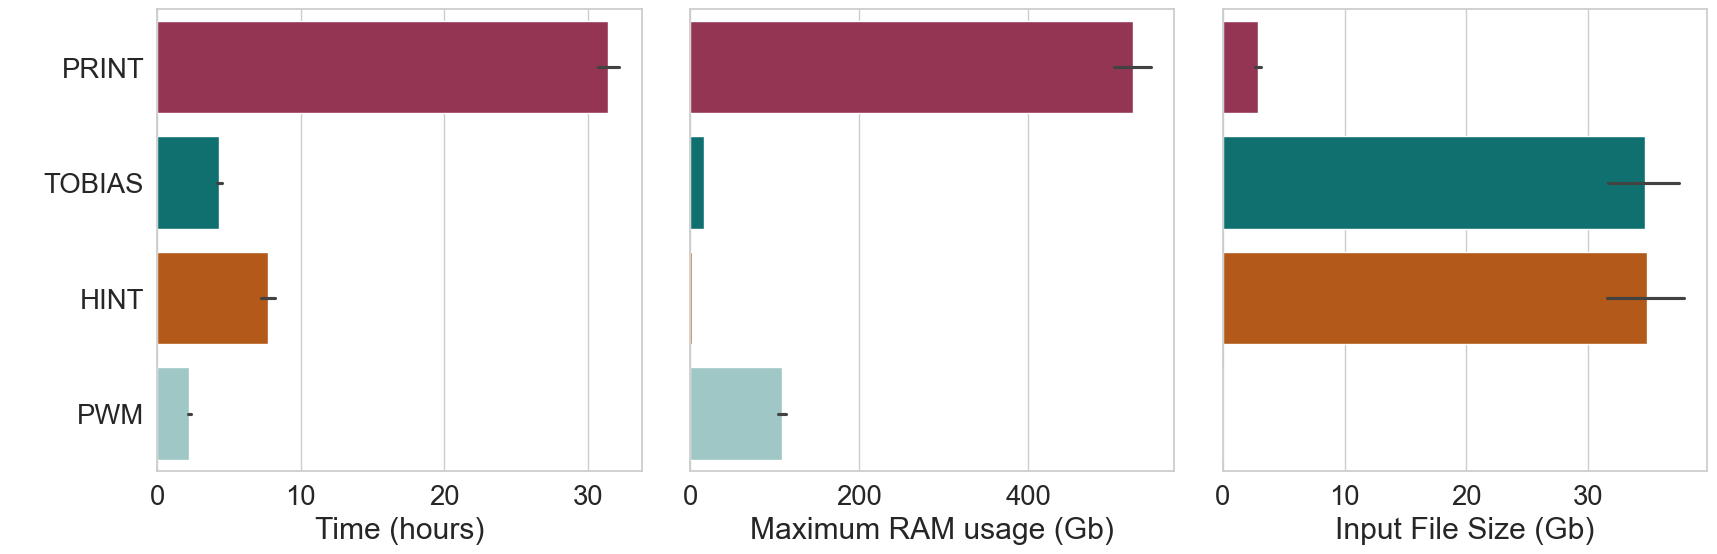

In [9]:
pal = {"TOBIAS":"#008080", "HINT":"#CC5500", "PRINT": "#A4254E", "PWM":'#97CECC'}

fig = plt.figure(figsize=(20, 6))
gs = GridSpec(1, 3, figure=fig, wspace=0.1)

sns.set(font_scale=1.8)
sns.set_style("whitegrid")

mem_df2 = mem_df[mem_df["program"] != "MACS3"]

ax0 = fig.add_subplot(gs[0])
sns.barplot(mem_df2, x="time(h)", y="program", legend=False, hue = "program", order=["PRINT","TOBIAS","HINT","PWM"], palette=pal)

ax1 = fig.add_subplot(gs[1])
sns.barplot(mem_df2, x="maxvmem(Gb)", y="program", legend=False, hue = "program", order=["PRINT","TOBIAS","HINT","PWM"], palette=pal)

ax2 = fig.add_subplot(gs[2])
sns.barplot(mem_df2, x="inputfilesize(Gb)", y="program", legend=False, hue = "program", order=["PRINT","TOBIAS","HINT","PWM"], palette=pal)


ax0.set_ylabel(" "); ax0.set_xlabel("Time (hours)")
ax1.set_ylabel(" "); ax1.set_xlabel("Maximum RAM usage (Gb)")
ax1.set_yticklabels([])
ax2.set_ylabel(" "); ax2.set_xlabel("Input File Size (Gb)")
ax2.set_yticklabels([])

plt.savefig("../12_manuscript_figures/FigS8_mem_requirements.svg")
plt.show()

In [10]:
pd.options.display.float_format = '{:.2f}'.format
df1 = mem_df[['program', "time(h)", "maxvmem(Gb)", "nproc", "inputfilesize(Gb)"]]

sd = df1.groupby('program').agg(np.std, ddof=1, axis=0)
m = df1.groupby('program').agg(np.mean, axis=0)

tmp_dict = {}
tmp_dict["program"] = m.index.values
for c in df1.columns.to_list():
    if c == "program": continue
    tmp_list = []
    for i in range(0, df1.shape[1]):
        m1 = m[c].values[i]
        sd1= sd[c].values[i]
        tmp_list.append(f"{m1:.2f} ± {sd1:.2f}")
    tmp_dict[c] = tmp_list

res = pd.DataFrame.from_dict(tmp_dict)
res.columns = ['program', 'time (h)', 'maxvmem (Gb)', 'nproc', 'inputfilesize (Gb)']
display(res)

,program,time (h),maxvmem (Gb),nproc,inputfilesize (Gb)
0,HINT,7.73 ± 4.52,2.82 ± 0.60,1.00 ± 0.00,34.89 ± 28.91
1,MACS3,0.47 ± 0.36,3.54 ± 2.09,5.00 ± 0.00,0.00 ± 0.00
2,PRINT,31.43 ± 6.62,524.13 ± 207.70,15.00 ± 0.00,2.89 ± 2.31
3,PWM,2.24 ± 0.92,108.51 ± 44.89,1.00 ± 0.00,0.02 ± 0.01
4,TOBIAS,4.32 ± 1.38,16.58 ± 3.22,8.00 ± 0.00,34.65 ± 28.84
